# Random forests and gradient boosting

## Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.set_up import set_up
import src.utility.util as utl


## Datasets

We have four datasets we want to train our models on:
* **A1**: A1 contains samples with and without review scores / sentiment features. Each sample has an indicator whether it had reviews or not. Missing values are filled with 0. (A1 is the dataset we obtain from 02_preprocessing.ipynb).
* **A2**: A2 contains only samples with all review scores and sentiment features.
* **B1**: B1 contains only samples without review scores. The review scores and sentiment columns are dropped after preprocessing.  
* **B2**: B2 contains samples with and without review scores. The review scores and sentiment columns are dropped after preprocessing.

All the other features are processed the same way in each set and the test set is the same for each set. See src/data/loading.py for more details.

The point is that not every listing has gotten reviews, especially new ones. Therefore we want to try models that do not rely on reviews.

We create all our datasets, so we can load and use them for training (see **src/set_up.py**).

In [2]:
# Preprocess the data and save it in .parquet files
load = True
if load:
    set_up()

c:\Users\Victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['boatslip', 'freeresortaccess', 'paidresortaccess', 'private_gym'] will be ignored
  warnings.warn(


## A1

### Load

In [3]:
# Load training and test sets
X_train_A1 = pd.read_parquet('../data/processed/A1/X_train.parquet', engine='pyarrow')
y_train_A1 = pd.read_parquet('../data/processed/A1/y_train.parquet', engine='pyarrow')
X_test_A1 = pd.read_parquet('../data/processed/A1/X_test.parquet', engine='pyarrow')
y_test_A1 = pd.read_parquet('../data/processed/A1/y_test.parquet', engine='pyarrow')

### Initialise RandomforestRegressor and GradientBoostingRegressor

In [4]:
# Random forest
rf_A1 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1   # CPU cores (-1 = all)
)

In [5]:
# Gradient Boosting
gb_A1 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

### Train

In [6]:
rf_A1.fit(X_train_A1, y_train_A1['price'])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [7]:
gb_A1.fit(X_train_A1, y_train_A1['price'])

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### Test

#### Randomforest

In [8]:
rf_predictions_A1_log = rf_A1.predict(X_test_A1)
prices_A1_log = y_test_A1['price'].to_list()

rf_predictions_A1 = np.expm1(rf_predictions_A1_log)
prices_A1 = np.expm1(prices_A1_log)

In [9]:
utl.show_errors(prices_A1_log, rf_predictions_A1_log)

===== TEST SET =====
RMSE: €98.84
MAE:  €41.73
Median AE:  €19.56
R²:   0.6648

R² (log-scale): 0.7965


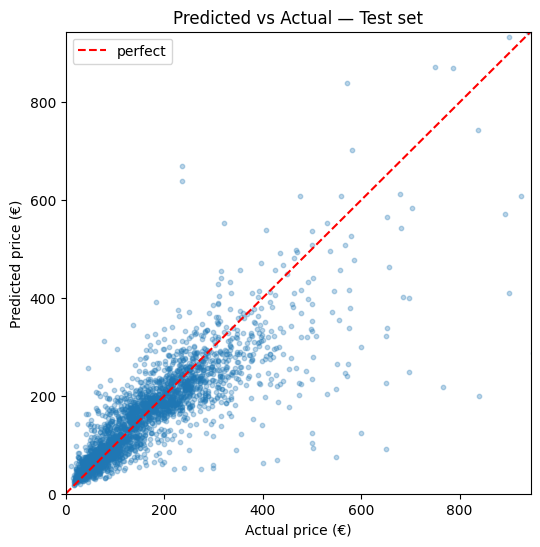

In [10]:
utl.plot_true_versus_predicted(prices_A1, rf_predictions_A1)

In [11]:
gb_predictions_A1_log = gb_A1.predict(X_test_A1)
gb_predictions_A1 = np.expm1(gb_predictions_A1_log)

In [12]:
utl.show_errors(prices_A1_log, gb_predictions_A1_log)

===== TEST SET =====
RMSE: €96.47
MAE:  €41.68
Median AE:  €20.24
R²:   0.6806

R² (log-scale): 0.8010


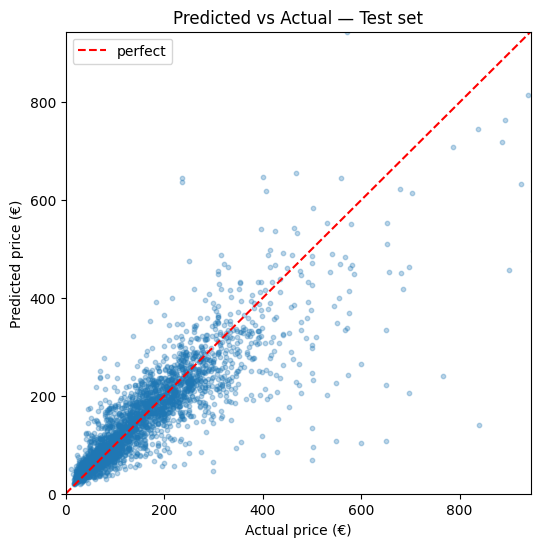

In [13]:
utl.plot_true_versus_predicted(prices_A1, gb_predictions_A1)

## A2

### Load

In [14]:
# Load training and test sets
X_train_A2 = pd.read_parquet('../data/processed/A2/X_train.parquet', engine='pyarrow')
y_train_A2 = pd.read_parquet('../data/processed/A2/y_train.parquet', engine='pyarrow')
X_test_A2 = pd.read_parquet('../data/processed/A2/X_test.parquet', engine='pyarrow')
y_test_A2 = pd.read_parquet('../data/processed/A2/y_test.parquet', engine='pyarrow')

### Initialise RandomforestRegressor and GradientBoostingRegressor

In [15]:
# Random forest
rf_A2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1   # CPU cores (-1 = all)
)

In [16]:
# Gradient Boosting
gb_A2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

### Train

In [17]:
rf_A2.fit(X_train_A2, y_train_A2['price'])
gb_A2.fit(X_train_A2, y_train_A2['price'])

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### Test
#### Randomforest

In [18]:
rf_predictions_A2_log = rf_A2.predict(X_test_A2)
prices_A2_log = y_test_A2['price'].to_list()
rf_predictions_A2 = np.expm1(rf_predictions_A2_log)
prices_A2 = np.expm1(prices_A2_log)

In [19]:
utl.show_errors(prices_A2_log, rf_predictions_A2_log)

===== TEST SET =====
RMSE: €106.02
MAE:  €44.93
Median AE:  €20.78
R²:   0.6142

R² (log-scale): 0.7623


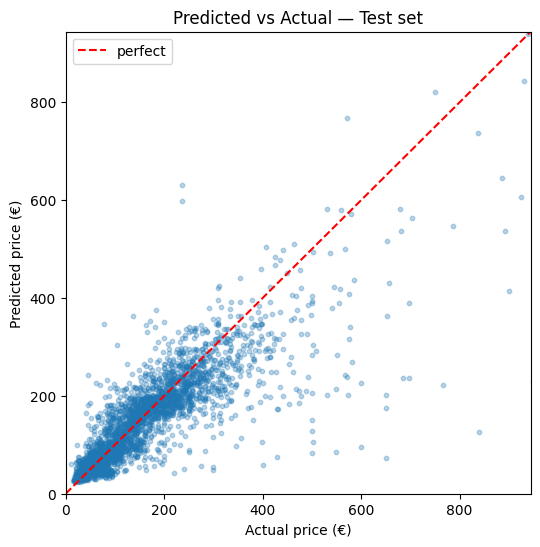

In [20]:
utl.plot_true_versus_predicted(prices_A2, rf_predictions_A2)

#### GradientBoosting

In [21]:

gb_predictions_A2_log = gb_A2.predict(X_test_A2)
gb_predictions_A2 = np.expm1(gb_predictions_A2_log)

In [22]:
utl.show_errors(prices_A2_log, gb_predictions_A2_log)

===== TEST SET =====
RMSE: €102.08
MAE:  €42.98
Median AE:  €20.55
R²:   0.6424

R² (log-scale): 0.7747


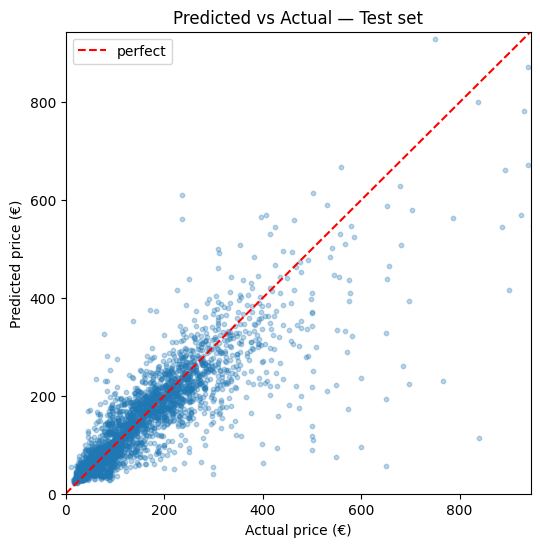

In [23]:
utl.plot_true_versus_predicted(prices_A2, gb_predictions_A2)

## B1

### Load

In [24]:
# Load training and test sets
X_train_B1 = pd.read_parquet('../data/processed/B1/X_train.parquet', engine='pyarrow')
y_train_B1 = pd.read_parquet('../data/processed/B1/y_train.parquet', engine='pyarrow')
X_test_B1 = pd.read_parquet('../data/processed/B1/X_test.parquet', engine='pyarrow')
y_test_B1 = pd.read_parquet('../data/processed/B1/y_test.parquet', engine='pyarrow')

### Initialise RandomforestRegressor and GradientBoostingRegressor

In [25]:
# Random forest
rf_B1 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1   # CPU cores (-1 = all)
)

In [26]:
# Gradient Boosting
gb_B1 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

### Train

In [27]:
rf_B1.fit(X_train_B1, y_train_B1['price'])
gb_B1.fit(X_train_B1, y_train_B1['price'])

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### Test
#### Randomforest

In [28]:
rf_predictions_B1_log = rf_B1.predict(X_test_B1)
prices_B1_log = y_test_B1['price'].to_list()
rf_predictions_B1 = np.expm1(rf_predictions_B1_log)
prices_B1 = np.expm1(prices_B1_log)

In [29]:
utl.show_errors(prices_B1_log, rf_predictions_B1_log)

===== TEST SET =====
RMSE: €110.33
MAE:  €54.35
Median AE:  €26.52
R²:   0.5823

R² (log-scale): 0.7056


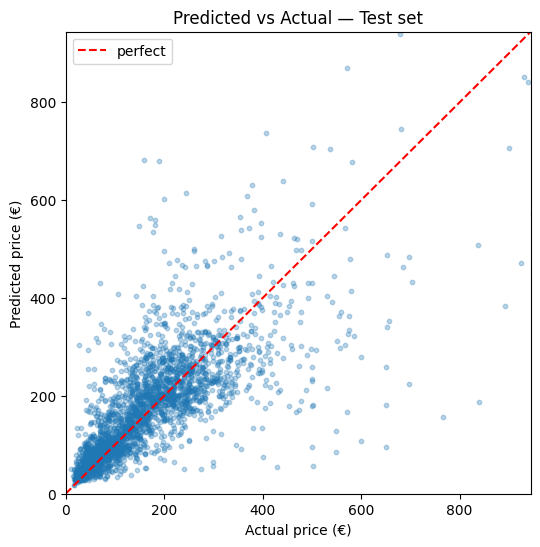

In [30]:
utl.plot_true_versus_predicted(prices_B1, rf_predictions_B1)

#### GradientBoosting

In [31]:
gb_predictions_B1_log = gb_B1.predict(X_test_B1)
gb_predictions_B1 = np.expm1(gb_predictions_B1_log)

In [32]:
utl.show_errors(prices_B1_log, gb_predictions_B1_log)

===== TEST SET =====
RMSE: €123.04
MAE:  €60.79
Median AE:  €28.17
R²:   0.4805

R² (log-scale): 0.6815


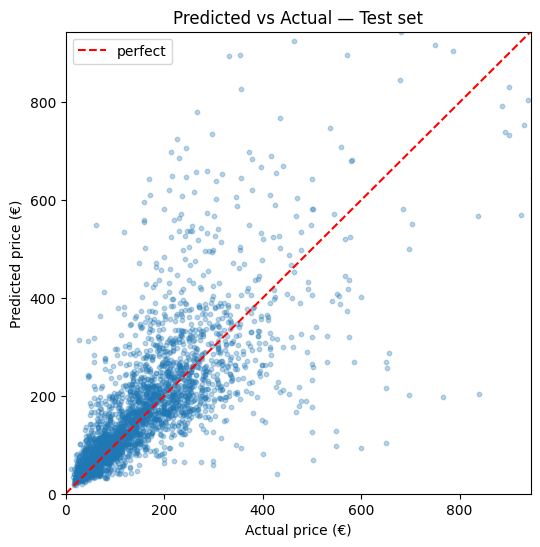

In [33]:
utl.plot_true_versus_predicted(prices_B1, gb_predictions_B1)

## B2

### Load

In [34]:
# Load training and test sets
X_train_B2 = pd.read_parquet('../data/processed/B2/X_train.parquet', engine='pyarrow')
y_train_B2 = pd.read_parquet('../data/processed/B2/y_train.parquet', engine='pyarrow')
X_test_B2 = pd.read_parquet('../data/processed/B2/X_test.parquet', engine='pyarrow')
y_test_B2 = pd.read_parquet('../data/processed/B2/y_test.parquet', engine='pyarrow')

### Initialise RandomforestRegressor and GradientBoostingRegressor

In [35]:
# Random forest
rf_B2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1   # CPU cores (-1 = all)
)

In [36]:
# Gradient Boosting
gb_B2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

### Train

In [37]:
rf_B2.fit(X_train_B2, y_train_B2['price'])
gb_B2.fit(X_train_B2, y_train_B2['price'])

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### Test
#### Randomforest

In [38]:
rf_predictions_B2_log = rf_B2.predict(X_test_B2)
prices_B2_log = y_test_B2['price'].to_list()
rf_predictions_B2 = np.expm1(rf_predictions_B2_log)
prices_B2 = np.expm1(prices_B2_log)

In [39]:
utl.show_errors(prices_B2_log, rf_predictions_B2_log)

===== TEST SET =====
RMSE: €98.00
MAE:  €40.70
Median AE:  €18.97
R²:   0.6704

R² (log-scale): 0.7997


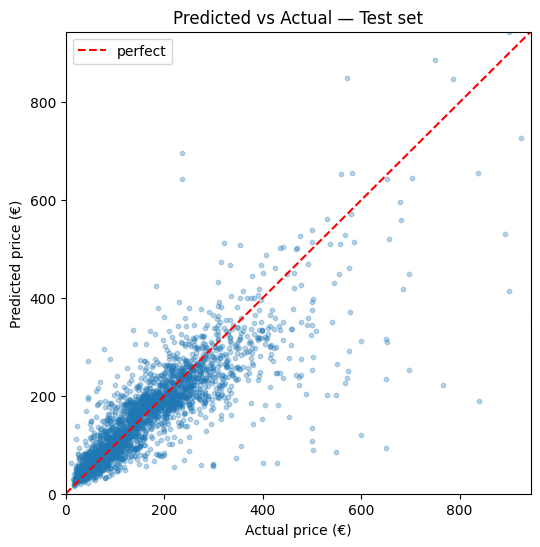

In [40]:
utl.plot_true_versus_predicted(prices_B2, rf_predictions_B2)

#### GradientBoosting

In [41]:
gb_predictions_B2_log = gb_B2.predict(X_test_B2)
gb_predictions_B2 = np.expm1(gb_predictions_B2_log)

In [42]:
utl.show_errors(prices_B2_log, gb_predictions_B2_log)

===== TEST SET =====
RMSE: €95.76
MAE:  €40.97
Median AE:  €19.99
R²:   0.6853

R² (log-scale): 0.8061


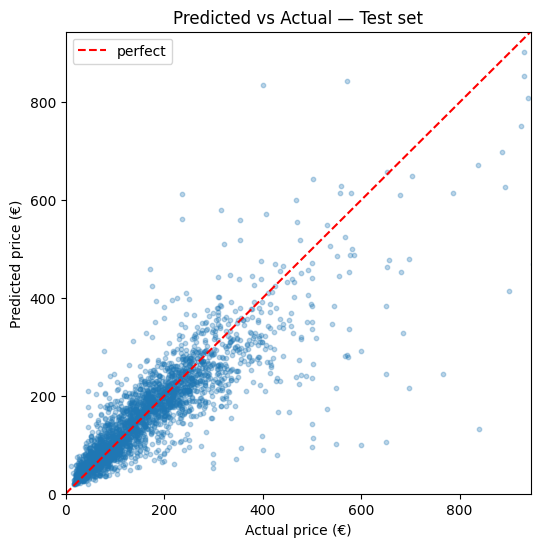

In [43]:
utl.plot_true_versus_predicted(prices_B2, gb_predictions_B2)